<a href="https://colab.research.google.com/github/AR-Ashik-9997/Phitron-practice-problem/blob/main/Mall_Customer_Segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
import warnings
warnings.filterwarnings('ignore')

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [16]:
df=pd.read_csv('/content/Mall_Customers.csv')
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [17]:
X=df[['Annual Income (k$)','Spending Score (1-100)']]
scale=StandardScaler()
X_scaled=scale.fit_transform(X)

Elbow method

In [27]:
w=[]
for k in range(1,10):
  k_means=KMeans(n_clusters=k,random_state=42)
  k_means.fit(X_scaled)
  w.append(k_means.inertia_)

print(k_means.cluster_centers_)

[[ 0.07722948 -0.11290604]
 [ 1.81769762  1.26275949]
 [ 0.73205646 -1.42897101]
 [-1.35921337  1.19570407]
 [-1.37320883 -1.57680239]
 [ 0.66703804  1.23036618]
 [-0.55987331  0.08456805]
 [ 1.87564575 -1.09476801]
 [-1.23585672 -0.65714315]]


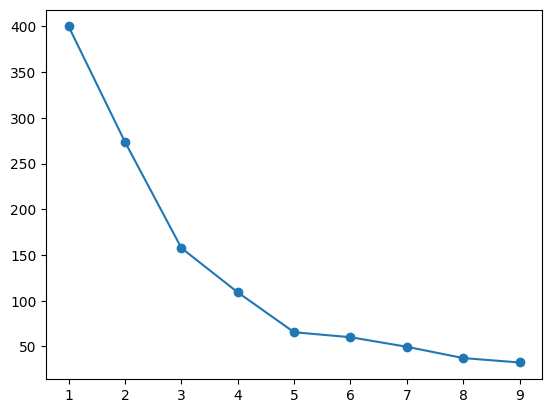

In [29]:
plt.plot(range(1,10),w,marker='o')
plt.show()

In [30]:
print(w)

[399.99999999999994, 273.66888662642003, 157.70400815035939, 109.22822707921345, 65.56840815571681, 60.132874871934206, 49.668244837367965, 37.31912287833882, 32.495081199100916]


In [19]:
cluster=k_means.fit_predict(X_scaled)
df['Cluster']=cluster
df

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,8
1,2,Male,21,15,81,3
2,3,Female,20,16,6,4
3,4,Female,23,16,77,3
4,5,Female,31,17,40,8
...,...,...,...,...,...,...
195,196,Female,35,120,79,1
196,197,Female,45,126,28,7
197,198,Male,32,126,74,1
198,199,Male,32,137,18,7


In [26]:
centers=scale.inverse_transform(k_means.cluster_centers_)
print(k_means.inertia_)
center_df=pd.DataFrame(
    centers,
    columns=['Annual Income (k$)','Spending Score (1-100)']
)
center_df

32.495081199100916


,Annual Income (k$),Spending Score (1-100)
0,62.583333,47.291667
1,108.181818,82.727273
2,79.739130,13.391304
3,24.950000,81.000000
4,24.583333,9.583333
5,78.035714,81.892857
6,45.891892,52.378378
7,109.700000,22.000000
8,28.181818,33.272727


when K=5

In [20]:
k_model=KMeans(n_clusters=5,random_state=42)
k_model.fit(X_scaled)

KMeans(n_clusters=5, random_state=42)

In [21]:
#cluster center coordinates
print(k_model.cluster_centers_)

[[-0.20091257 -0.02645617]
 [ 0.99158305  1.23950275]
 [-1.32954532  1.13217788]
 [ 1.05500302 -1.28443907]
 [-1.30751869 -1.13696536]]


In [22]:
clusters=k_model.fit_predict(X_scaled)
df['Cluster']=clusters
df

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4
...,...,...,...,...,...,...
195,196,Female,35,120,79,1
196,197,Female,45,126,28,3
197,198,Male,32,126,74,1
198,199,Male,32,137,18,3


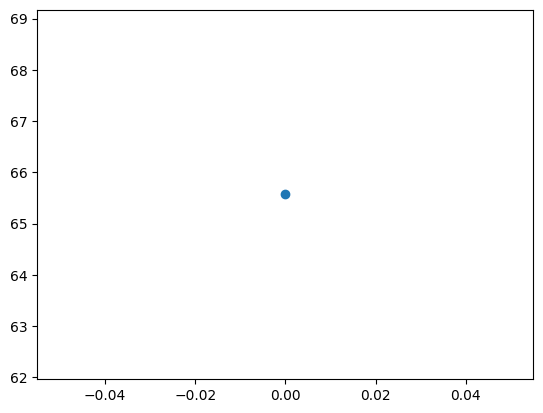

In [31]:
plt.plot(k_model.inertia_,marker='o')
plt.show()

In [24]:
# luxury product
k_centers=scale.inverse_transform(k_model.cluster_centers_)
center_df=pd.DataFrame(
    k_centers,
    columns=['Annual Income (k$)','Spending Score (1-100)']
)
center_df

,Annual Income (k$),Spending Score (1-100)
0,55.296296,49.518519
1,86.538462,82.128205
2,25.727273,79.363636
3,88.200000,17.114286
4,26.304348,20.913043
